In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [3]:
df = pd.read_csv("Train.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [5]:
df = df.fillna(df.median(numeric_only=True))

In [6]:
features = [
    'Cost_of_the_Product',
    'Weight_in_gms',
    'Discount_offered',
    'Customer_rating'
]
X = df[features]
y = df['Reached.on.Time_Y.N']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,Cost_of_the_Product,Weight_in_gms,Discount_offered,Customer_rating
0,-0.690722,-1.468240,1.889983,-0.700755
1,0.120746,-0.333893,2.815636,1.421578
2,-0.565881,-0.159002,2.136824,-0.700755
3,-0.711529,-1.502484,-0.208162,0.006689
4,-0.545074,-0.703244,2.013404,-0.700755


In [8]:
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X_scaled.columns[selector.get_support()]
print("Top Selected Features:", selected_features.tolist())

Top Selected Features: ['Weight_in_gms', 'Discount_offered']


In [9]:
scores = pd.DataFrame({
    "Feature": features,
    "Score": selector.scores_
})
scores.sort_values(by="Score", ascending=False)

,Feature,Score
2,Discount_offered,2058.842985
1,Weight_in_gms,856.401798
0,Cost_of_the_Product,59.873829
3,Customer_rating,1.892885


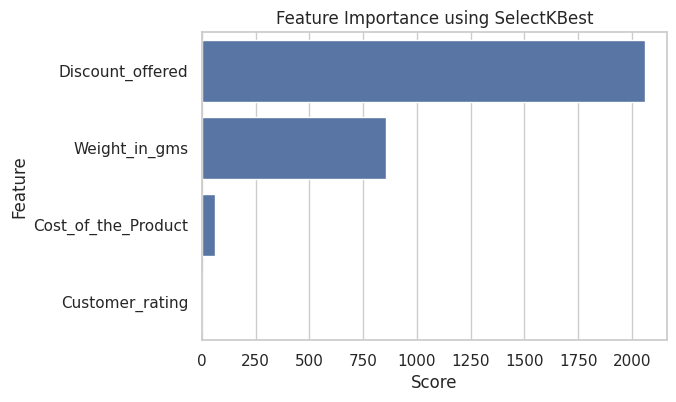

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="Score",
    y="Feature",
    data=scores.sort_values(by="Score", ascending=False)
)
plt.title("Feature Importance using SelectKBest")
plt.show()